# Phase 1.2 — Manipulator per-sample slack diagnostic

Two-link manipulator counterpart of `dubins_slack_diag.ipynb`. The two
torque channels live at very different scales ($\tau_1\sim$ thousands,
$\tau_2\sim$ hundreds), so **everything below is per channel**: slack
distributions, the kept-subset selection, and the effective bounds
$u_{\max}^{\rm eff}=(\tau_1^{\rm eff},\tau_2^{\rm eff})$.

Self-contained: reads only `revision/data/phase1_1_outputs_manipulator.json`
(the $\mathcal X_S^{\rm eff}$ box) and triggers the frozen MATLAB solver
`revision/slack_diagnostic/solve_manipulator_slack.m`; writes only to
`revision/data/`. **All parameter settings are defined and triggered from
this notebook** (§1); the `.m` sets no parameter values.


## §0 — Per-sample slack SOP (what `solve_manipulator_slack.m` solves)

On the manifold $x_5=x_1+x_2$, draw $N$ valid reach-avoid states
$\mathcal S_0$ in the $\mathcal X_S^{\rm eff}$ box (Phase 1.1). Keep the
reach-avoid SOS constraints **hard** and relax only the per-channel torque
bounds with a non-negative slack at every sample:

$$
-u_{\max,i}-s_{j,i}\;\le\; u^*_i(\bm x_j)\;\le\; u_{\max,i}+s_{j,i},
\qquad s_{j,i}\ge 0,\quad i\in\{1,2\},\ j=1,\dots,N,
$$

minimising $\delta + w\sum_{j,i} s_{j,i}$. The slacks $s_{j,i}$ are a
**diagnostic only** (no controller is exported here): they tell us which
samples are hard for each channel and how far the achievable bound sits
above the requested one.

The manipulator decoupling matrix is singular as $q_2\to\{0,\pi\}$
($\det A\propto\sin q_2$, Phase 1.1), so we expect the hardest samples to
cluster toward the $q_2$ boundaries of $\mathcal X_S^{\rm eff}$.


## §1 — Parameters (single source of truth) + MATLAB trigger helper

Everything the solver needs is set here and pushed to MATLAB through
environment variables (`ENV`). Four groups:

1. **synthesis / SOP** — backstepping & SOS knobs (`mu, xi0, ds, dv`), the
   requested per-channel torque bounds (`ub1, ub2`), sample count
   (`n_valid_samples`) and the slack penalty weight (`slack_weight`);
2. **sampling** — the RNG `seed` (reproducibility of $\mathcal S_0$);
3. **system model** — the manipulator physical constants
   (`m1, m2, l1, l2, lc1, lc2, I1, I2, g`);
4. **notebook-side selection** — `coverage_pct`, `slack_floor` (applied in
   §4 with no MATLAB re-run).

`PROBLEM_DEF` documents the frozen example geometry (EOM form, output map,
safe / target sets) realised in `solve_manipulator_slack.m`; it is shown
read-only for completeness and is _not_ a tunable knob.


In [15]:
import json
import os
import shutil
import subprocess

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# locate repo ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
SLACK_DIR = os.path.join(REV, "slack_diagnostic")
REV_DATA = os.path.join(REV, "data")
os.makedirs(REV_DATA, exist_ok=True)
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

# ============================ ALL PARAMETERS =============================
# Single source of truth. Anything the MATLAB solver needs is set here and
# pushed via ENV; solve_manipulator_slack.m sets no parameter values.
PARAMS = {
    # --- (1) synthesis / SOP --------------------------------------------
    "mu": 15,  # backstepping certificate parameter (paper baseline)
    "xi0": 1e-8,  # SOS floor lambda >= xi0 for the vanilla k1 (descent rate)
    "ub1": 500.0,  # requested (tight) bound on |tau1|; paper nominal
    "ub2": 500.0,  # requested (tight) bound on |tau2|; paper nominal
    "n_valid_samples": 250,  # number of valid reach-avoid SOP samples
    "slack_weight": 100.0,  # weight w on sum of per-sample slacks in the objective
    "ds": 4,  # SOS auxiliary degree
    "dv": 2,  # k1 polynomial degree
    # --- (2) sampling ---------------------------------------------------
    "seed": 42,  # RNG seed for the manifold reach-avoid sampler
    # --- (3) manipulator physical constants (system model) --------------
    "m1": 1.0,
    "m2": 1.0,  # link masses
    "l1": 4.0,
    "l2": 4.0,  # link lengths
    "lc1": 2.0,
    "lc2": 2.0,  # mass-center distances
    "I1": 0.02,
    "I2": 0.02,  # link inertias
    "g": 9.81,  # gravity
    # --- (4) notebook-side selection (no MATLAB re-run needed) ----------
    "coverage_pct": 80,  # keep the lowest-q% of samples by combined RELATIVE slack
    "slack_floor": 1e-2,  # below this, slack is the solver's numerical zero
}

# Frozen example definition (read-only mirror of solve_manipulator_slack.m).
# Documented here for completeness; NOT passed to MATLAB and NOT a tunable knob.
PROBLEM_DEF = {
    "state": "x = [q1, q2, dq1, dq2, q1+q2]  (5-D augmented; manifold x5 = x1 + x2)",
    "inputs": "u = [tau1, tau2]  (joint torques)",
    "eom": "two-link planar arm  ddq = M(q)^{-1}(-C(q,dq) dq - G(q)) + M(q)^{-1} tau",
    "output": "y = [l1 cos q1 + l2 cos(q1+q2),  l1 sin q1 + l2 sin(q1+q2)]  (end-effector)",
    "safe_set": "-((4*(y1-2) - 2*y2^3)^2) + 0.8*y2^3 + 10 >= 0",
    "target_set": "((y1-5.5)^2)/1.2^2 + ((y2-1.8)^2)/0.4^2 - 2 <= 0",
}

ENV = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB1": PARAMS["ub1"],
    "UB2": PARAMS["ub2"],
    "N_VALID": PARAMS["n_valid_samples"],
    "SLACK_WEIGHT": PARAMS["slack_weight"],
    "DS": PARAMS["ds"],
    "DV": PARAMS["dv"],
    "SEED": PARAMS["seed"],
    "M1": PARAMS["m1"],
    "M2": PARAMS["m2"],
    "L1": PARAMS["l1"],
    "L2": PARAMS["l2"],
    "LC1": PARAMS["lc1"],
    "LC2": PARAMS["lc2"],
    "I1": PARAMS["I1"],
    "I2": PARAMS["I2"],
    "GRAV": PARAMS["g"],
}

# forward kinematics for the workspace y-plots (uses the SAME l1,l2 as the solver)
L1, L2 = PARAMS["l1"], PARAMS["l2"]


def fk(x1, x5):
    """end-effector output y = (y1, y2) from joint angles q1=x1, q1+q2=x5."""
    return L1 * np.cos(x1) + L2 * np.cos(x5), L1 * np.sin(x1) + L2 * np.sin(x5)


def run_matlab(script_name, env_overrides):
    """Run a revision MATLAB driver with ONLY the revision dirs on the path."""
    env = os.environ.copy()
    env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{SLACK_DIR}'); "
        f"try, {script_name}; catch e, fprintf(2,'%s\\n',e.message); exit(1); end; exit(0);",
    ]
    import sys
    import time

    t0 = time.time()
    proc = subprocess.Popen(
        cmd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    lines = []
    for raw in proc.stdout:  # stream MATLAB stdout live
        line = raw.rstrip()
        lines.append(line)
        print(f"[matlab +{time.time() - t0:6.0f}s] {line}")
        sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(
            f"MATLAB {script_name} failed (rc={proc.returncode}); last lines:"
            + chr(10)
            + chr(10).join(lines[-20:])
        )
    return chr(10).join(lines)


print("ROOT       :", ROOT)
print("MATLAB_BIN :", MATLAB_BIN, "(exists:", os.path.exists(MATLAB_BIN), ")")
print("parameters (notebook is the single source of truth):")
for k, v in PARAMS.items():
    print(f"  {k:16s} = {v}")
print("frozen problem definition (mirrors solve_manipulator_slack.m):")
for k, v in PROBLEM_DEF.items():
    print(f"  {k:11s}: {v}")

ROOT       : /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC
MATLAB_BIN : /usr/local/bin/matlab (exists: True )
parameters (notebook is the single source of truth):
  mu               = 15
  xi0              = 1e-08
  ub1              = 500.0
  ub2              = 500.0
  n_valid_samples  = 250
  slack_weight     = 100.0
  ds               = 4
  dv               = 2
  seed             = 42
  m1               = 1.0
  m2               = 1.0
  l1               = 4.0
  l2               = 4.0
  lc1              = 2.0
  lc2              = 2.0
  I1               = 0.02
  I2               = 0.02
  g                = 9.81
  coverage_pct     = 80
  slack_floor      = 0.01
frozen problem definition (mirrors solve_manipulator_slack.m):
  state      : x = [q1, q2, dq1, dq2, q1+q2]  (5-D augmented; manifold x5 = x1 + x2)
  inputs     : u = [tau1, tau2]  (joint torques)
  eom        : two-link planar arm  ddq = M(q)^{-1}(-C(q,dq) dq - G(q)) + M(q)^{-1} tau
  output     : y = [l1 cos q1 + l2 co

## §2 — Trigger the MATLAB per-sample slack SOP, then load the result


In [16]:
PS_PATH = os.path.join(REV_DATA, "slack_persample_manipulator.csv")
META_PATH = os.path.join(REV_DATA, "slack_meta_manipulator.csv")
REGENERATE = False

# (PARAM key, meta column, tolerance) -- any change beyond tol re-runs MATLAB.
watched = [
    ("mu", "mu", 1e-9),
    ("xi0", "xi0", 1e-9),
    ("ub1", "ub1_req", 1e-9),
    ("ub2", "ub2_req", 1e-9),
    ("n_valid_samples", "n_valid_samples", 0.5),
    ("slack_weight", "slack_weight", 1e-9),
    ("ds", "ds", 0.5),
    ("dv", "dv", 0.5),
    ("seed", "seed", 0.5),
    ("m1", "m1", 1e-9),
    ("m2", "m2", 1e-9),
    ("l1", "l1", 1e-9),
    ("l2", "l2", 1e-9),
    ("lc1", "lc1", 1e-9),
    ("lc2", "lc2", 1e-9),
    ("I1", "I1", 1e-9),
    ("I2", "I2", 1e-9),
    ("g", "g", 1e-9),
]
need = REGENERATE or not (os.path.exists(PS_PATH) and os.path.exists(META_PATH))
if not need:
    cached = pd.read_csv(META_PATH).iloc[0]
    for pkey, ckey, tol in watched:
        if ckey not in cached.index:
            print(
                f"note: cached meta has no '{ckey}' (legacy) -> not forcing regenerate"
            )
            continue
        if abs(float(cached[ckey]) - float(PARAMS[pkey])) > tol:
            need = True
            print(f"cache miss on '{ckey}' -> regenerate")
            break

if need:
    print("running solve_manipulator_slack.m (MATLAB) ...")
    out = run_matlab("solve_manipulator_slack", ENV)
    print("\n".join(out.strip().splitlines()[-10:]))
else:
    print("cached outputs match PARAMS -> skipping MATLAB.")

df = pd.read_csv(PS_PATH)
meta = pd.read_csv(META_PATH).iloc[0]
UB1_REQ = float(meta["ub1_req"])
UB2_REQ = float(meta["ub2_req"])

# end-effector output (workspace) for the spatial plots
df["y1"], df["y2"] = fk(df["x1"].values, df["x5"].values)
# per-channel RELATIVE slack and a combined (worst relative channel) score
df["rel1"] = df["slack1"] / UB1_REQ
df["rel2"] = df["slack2"] / UB2_REQ
df["rel"] = df[["rel1", "rel2"]].max(axis=1)

print(
    f"\nloaded {len(df)} samples; ub_req=(tau1<={UB1_REQ:g}, tau2<={UB2_REQ:g}), "
    f"seed={int(meta['seed']) if 'seed' in meta.index else PARAMS['seed']}, "
    f"lambda={meta['lambda']:.4g}, delta={meta['delta']:.4g}"
)
for c, ub in [("slack1", UB1_REQ), ("slack2", UB2_REQ)]:
    s = df[c].values
    print(
        f"  {c} (ub={ub:g}): p50={np.percentile(s,50):.4g} p80={np.percentile(s,80):.4g} "
        f"p90={np.percentile(s,90):.4g} p95={np.percentile(s,95):.4g} max={s.max():.4g} "
        f"| nz(>1e-6)={100*np.mean(s>1e-6):.1f}%"
    )

cached outputs match PARAMS -> skipping MATLAB.

loaded 250 samples; ub_req=(tau1<=500, tau2<=500), seed=42, lambda=1.872e-07, delta=2520
  slack1 (ub=500): p50=3.579e-07 p80=179.2 p90=532.5 p95=1080 max=2580 | nz(>1e-6)=33.6%
  slack2 (ub=500): p50=3.098e-07 p80=3.777e-07 p90=4.248e-07 p95=6.356 max=267.4 | nz(>1e-6)=5.6%


## §3 — Per-channel slack distributions

Row 1 = $\tau_1$, row 2 = $\tau_2$. Histogram (log slack), sorted-slack
elbow, and CDF with effective-bound annotations $u_{\max,i}^{\rm eff}=u_{\max,i}+\text{quantile}$.


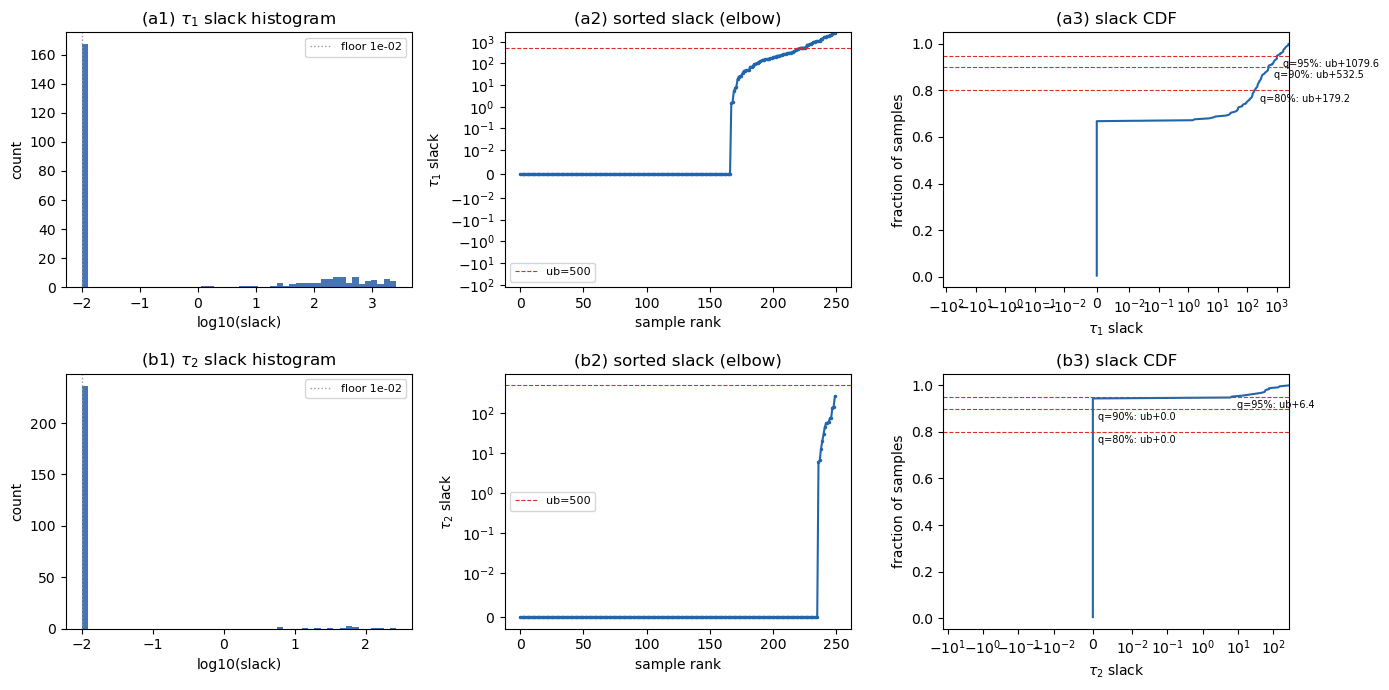

$\tau_1$: fraction with slack <= floor (1e-02): 66.8% (feasible at ub=500 with ~0 slack)
$\tau_2$: fraction with slack <= floor (1e-02): 94.4% (feasible at ub=500 with ~0 slack)


In [17]:
FLOOR = PARAMS["slack_floor"]
channels = [("slack1", UB1_REQ, r"$\tau_1$"), ("slack2", UB2_REQ, r"$\tau_2$")]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (col, ub, lab) in enumerate(channels):
    s = df[col].values
    s_sorted = np.sort(s)
    cdf = np.arange(1, len(s) + 1) / len(s)

    ax = axes[row, 0]
    ax.hist(np.log10(np.clip(s, FLOOR, None)), bins=50, color="#4575b4")
    ax.axvline(
        np.log10(FLOOR), color="#999999", ls=":", lw=1, label=f"floor {FLOOR:.0e}"
    )
    ax.set_xlabel("log10(slack)")
    ax.set_ylabel("count")
    ax.set_title(f"({chr(97+row)}1) {lab} slack histogram")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(np.arange(len(s)), s_sorted, ".-", ms=3, color="#2166ac")
    ax.axhline(ub, color="#d73027", ls="--", lw=0.8, label=f"ub={ub:g}")
    ax.set_xlabel("sample rank")
    ax.set_ylabel(f"{lab} slack")
    ax.set_title(f"({chr(97+row)}2) sorted slack (elbow)")
    ax.set_yscale("symlog", linthresh=FLOOR)
    ax.legend(fontsize=8)

    ax = axes[row, 2]
    ax.plot(s_sorted, cdf, color="#2166ac")
    for q in (0.8, 0.9, 0.95):
        thr = np.quantile(s, q)
        ax.axhline(q, color="#d73027", ls="--", lw=0.8)
        ax.annotate(
            f"q={q:.0%}: ub+{thr:.1f}",
            (thr, q),
            fontsize=7,
            xytext=(4, -8),
            textcoords="offset points",
        )
    ax.set_xlabel(f"{lab} slack")
    ax.set_ylabel("fraction of samples")
    ax.set_title(f"({chr(97+row)}3) slack CDF")
    ax.set_xscale("symlog", linthresh=FLOOR)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_manipulator_distribution.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

for col, ub, lab in channels:
    s = df[col].values
    print(
        f"{lab}: fraction with slack <= floor ({FLOOR:.0e}): {100*np.mean(s <= FLOOR):.1f}% "
        f"(feasible at ub={ub:g} with ~0 slack)"
    )

## §3.2 — Where are the hard samples?

Per channel, slack over joint config $(q_1,q_2)$, joint velocity
$(\dot q_1,\dot q_2)$, and end-effector workspace $(y_1,y_2)$. The last
row checks the FL-singularity hypothesis: slack vs $|\sin q_2|$ (a proxy
for $|\det A|$, which $\propto\sin q_2$) — hard samples should sit at
small $|\sin q_2|$, i.e. near the $q_2$ boundaries.


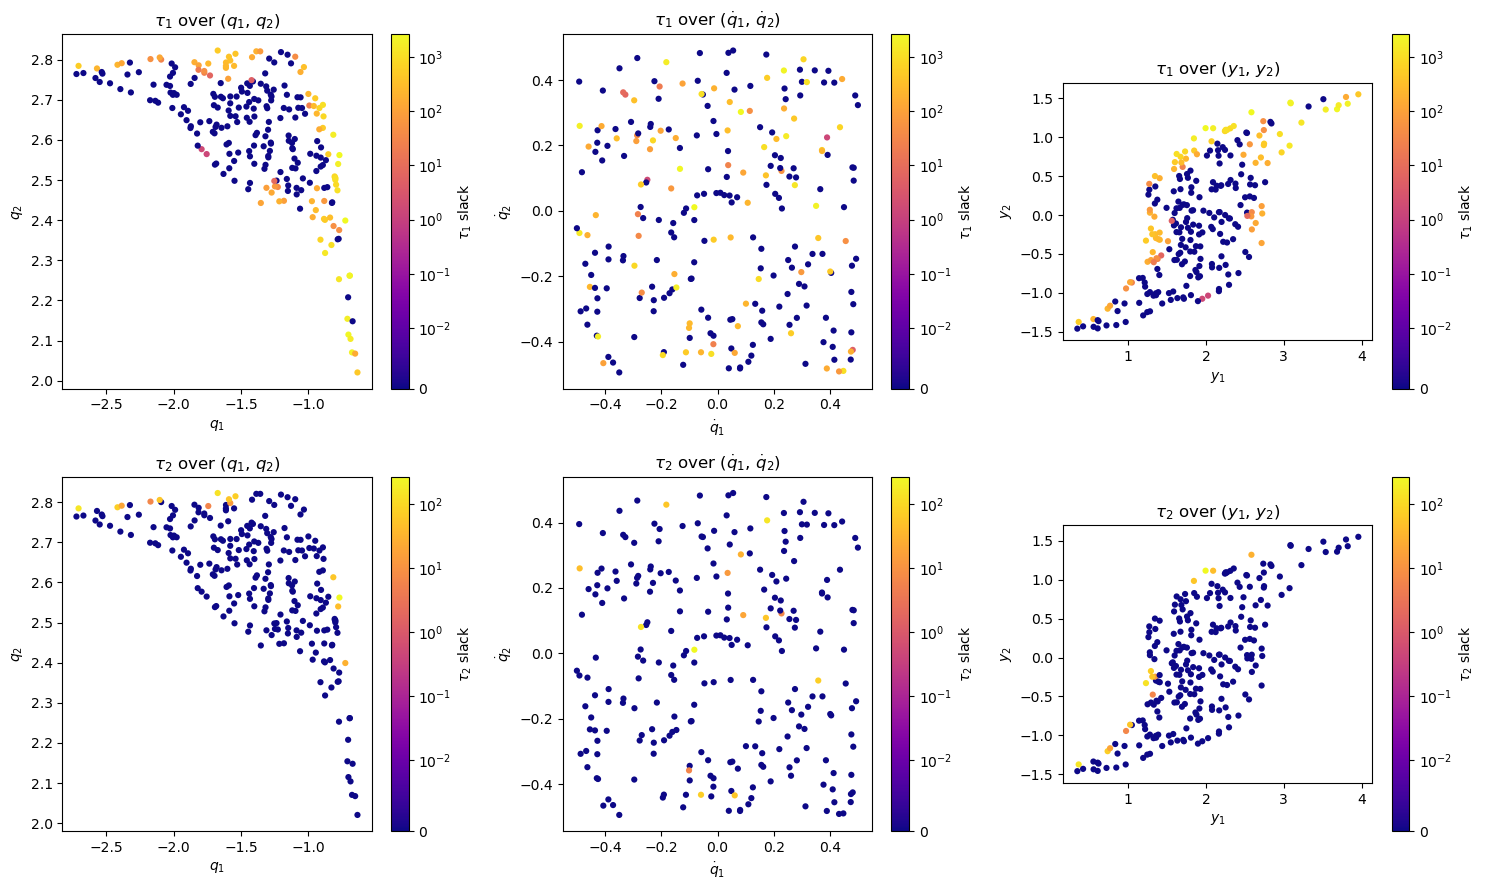

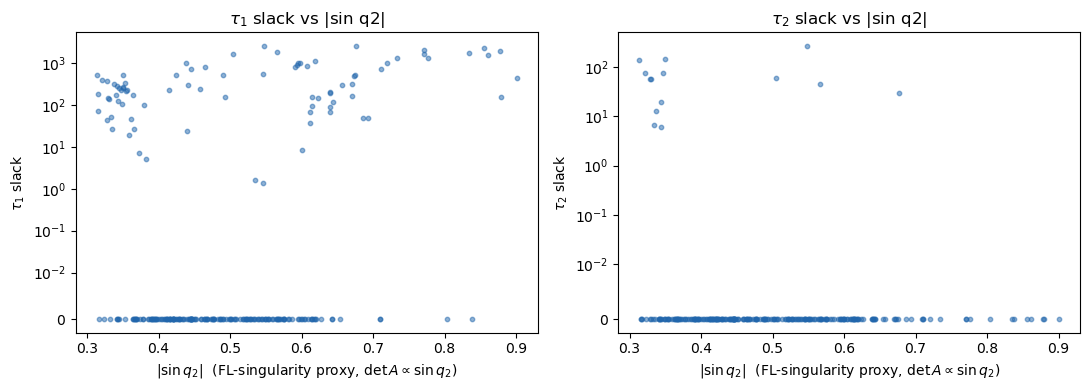

In [18]:
proj = [
    ("x1", "x2", r"$q_1$", r"$q_2$"),
    ("x3", "x4", r"$\dot q_1$", r"$\dot q_2$"),
    ("y1", "y2", r"$y_1$", r"$y_2$"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (col, ub, lab) in enumerate(channels):
    s = df[col].values
    norm = mcolors.SymLogNorm(
        linthresh=max(FLOOR, 1e-2), vmin=0, vmax=max(s.max(), FLOOR)
    )
    for k, (cx, cy, lx, ly) in enumerate(proj):
        ax = axes[row, k]
        sc = ax.scatter(
            df[cx], df[cy], c=s, cmap="plasma", norm=norm, s=20, edgecolors="none"
        )
        plt.colorbar(sc, ax=ax, label=f"{lab} slack")
        ax.set_xlabel(lx)
        ax.set_ylabel(ly)
        ax.set_title(f"{lab} over ({lx}, {ly})")
        if k == 2:
            ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_manipulator_spatial.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

# FL-singularity check: slack vs |sin q2| (det A propto sin q2)
sin_q2 = np.abs(np.sin(df["x2"].values))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (col, ub, lab) in zip(axes, channels):
    ax.scatter(sin_q2, df[col], s=10, c="#2166ac", alpha=0.5)
    ax.set_xlabel(r"$|\sin q_2|$  (FL-singularity proxy, $\det A\propto\sin q_2$)")
    ax.set_ylabel(f"{lab} slack")
    ax.set_yscale("symlog", linthresh=max(FLOOR, 1e-2))
    ax.set_title(f"{lab} slack vs |sin q2|")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_manipulator_vs_sinq2.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §4 — Per-channel effective bounds (80th-pct slack, rounded up) + kept subset

For each channel we take the $80$th-percentile slack, **round it up to one
decimal place** ($s_i^{\rm thr}$), and set
$u_i^{\rm eff}=u_{\max,i}+s_i^{\rm thr}$ — so both bounds carry at most one
decimal. A sample is **kept** iff both channels are within their rounded
thresholds ($s_{j,1}\le s_1^{\rm thr}$ and $s_{j,2}\le s_2^{\rm thr}$); the
rest are dropped.


coverage = 80%  (threshold = ceil-to-0.1 of the 80th pct slack)
kept 197 / 250  (78.8%);  dropped 53
  tau1: s_thr = 179.2  ->  u_max_eff = 500 + 179.2 = 679.2  (slack/ub = 0.36 -> loose -> lower coverage or revisit region)
  tau2: s_thr = 0.1  ->  u_max_eff = 500 + 0.1 = 500.1  (slack/ub = 0.00 -> tight (~nominal))


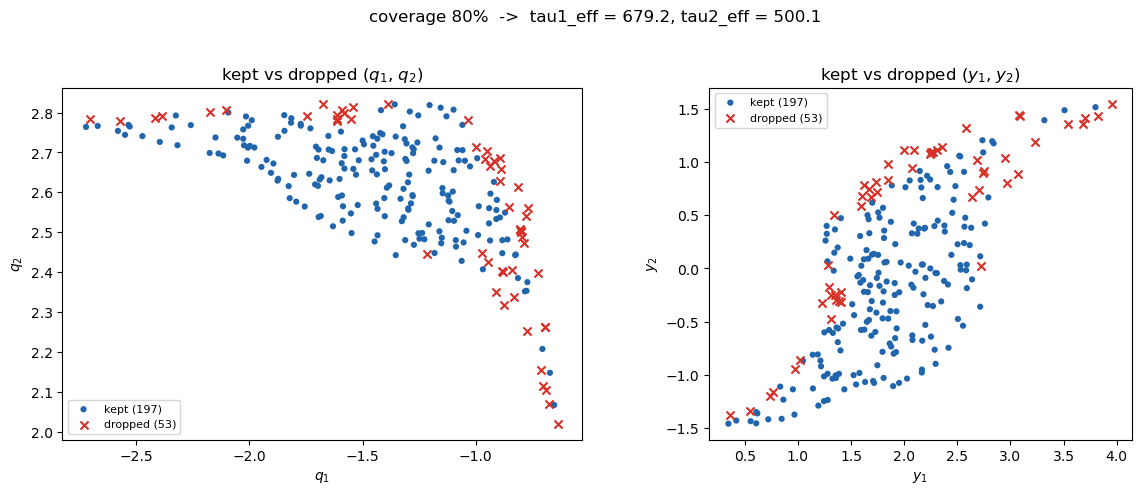

In [19]:
COVERAGE_PCT = PARAMS["coverage_pct"]


def ceil_1dp(x):
    """round UP to 1 decimal place (FP-robust)."""
    return float(np.ceil(round(x * 10.0, 6)) / 10.0)


# per-channel slack allowance: the COVERAGE_PCT-th percentile slack, rounded
# UP to 1 decimal place. This rounded value is BOTH the selection threshold
# and the increment added to the nominal bound, so the effective bounds carry
# at most 1 decimal place.
s_thr = {
    "tau1": ceil_1dp(np.percentile(df["slack1"].values, COVERAGE_PCT)),
    "tau2": ceil_1dp(np.percentile(df["slack2"].values, COVERAGE_PCT)),
}
ub_eff = {
    "tau1": round(UB1_REQ + s_thr["tau1"], 1),
    "tau2": round(UB2_REQ + s_thr["tau2"], 1),
}
ratio = {
    "tau1": (ub_eff["tau1"] - UB1_REQ) / UB1_REQ,
    "tau2": (ub_eff["tau2"] - UB2_REQ) / UB2_REQ,
}

# kept = samples within BOTH per-channel rounded slack thresholds
keep_mask = (df["slack1"] <= s_thr["tau1"]) & (df["slack2"] <= s_thr["tau2"])
kept = df[keep_mask].copy()
dropped = df[~keep_mask].copy()


def verdict(r):
    return (
        "tight (~nominal)"
        if r <= 0.05
        else "acceptable" if r <= 0.30 else "loose -> lower coverage or revisit region"
    )


print(
    f"coverage = {COVERAGE_PCT}%  (threshold = ceil-to-0.1 of the {COVERAGE_PCT}th pct slack)"
)
print(
    f"kept {len(kept)} / {len(df)}  ({100*len(kept)/len(df):.1f}%);  dropped {len(dropped)}"
)
for ch, ub in [("tau1", UB1_REQ), ("tau2", UB2_REQ)]:
    print(
        f"  {ch}: s_thr = {s_thr[ch]:.1f}  ->  u_max_eff = {ub:g} + {s_thr[ch]:.1f} = {ub_eff[ch]:.1f}  "
        f"(slack/ub = {ratio[ch]:.2f} -> {verdict(ratio[ch])})"
    )

proj_keep = [("x1", "x2", r"$q_1$", r"$q_2$"), ("y1", "y2", r"$y_1$", r"$y_2$")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (cx, cy, lx, ly) in zip(axes, proj_keep):
    ax.scatter(
        kept[cx],
        kept[cy],
        s=20,
        c="#2166ac",
        label=f"kept ({len(kept)})",
        edgecolors="none",
    )
    ax.scatter(
        dropped[cx],
        dropped[cy],
        s=34,
        c="#d73027",
        marker="x",
        label=f"dropped ({len(dropped)})",
    )
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.legend(fontsize=8)
    ax.set_title(f"kept vs dropped ({lx}, {ly})")
axes[1].set_aspect("equal")
fig.suptitle(
    f"coverage {COVERAGE_PCT}%  ->  tau1_eff = {ub_eff['tau1']:.1f}, tau2_eff = {ub_eff['tau2']:.1f}",
    y=1.02,
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, "slack_manipulator_kept.png"), dpi=130, bbox_inches="tight"
)
plt.show()

## §5 — Export Phase 1.2 outputs


In [20]:
kept_path = os.path.join(REV_DATA, "kept_samples_manipulator.csv")
kept[["sample_idx", "x1", "x2", "x3", "x4", "x5", "slack1", "slack2"]].to_csv(
    kept_path, index=False
)

phys = ["m1", "m2", "l1", "l2", "lc1", "lc2", "I1", "I2", "g"]
out = {
    "phase": "1.2",
    "example": "manipulator",
    "self_contained": True,
    "probe": {
        "mu": float(meta["mu"]),
        "xi0": float(meta["xi0"]),
        "ub_req": {"tau1": UB1_REQ, "tau2": UB2_REQ},
        "slack_weight": float(meta["slack_weight"]),
        "ds": float(meta["ds"]),
        "dv": float(meta["dv"]),
        "seed": int(meta["seed"]) if "seed" in meta.index else PARAMS["seed"],
        "lambda": float(meta["lambda"]),
        "delta": float(meta["delta"]),
        "n_samples": int(len(df)),
    },
    "system_constants": {
        k: (float(meta[k]) if k in meta.index else PARAMS[k]) for k in phys
    },
    "coverage_pct": COVERAGE_PCT,
    "slack_threshold": s_thr,
    "u_max_eff": ub_eff,
    "u_max_eff_over_ub_req": {
        "tau1": ub_eff["tau1"] / UB1_REQ,
        "tau2": ub_eff["tau2"] / UB2_REQ,
    },
    "n_kept": int(len(kept)),
    "n_dropped": int(len(dropped)),
    "kept_samples_csv": os.path.relpath(kept_path, ROOT),
    "slack_quantiles": {
        "tau1": {
            q: float(np.percentile(df["slack1"], q)) for q in (50, 80, 90, 95, 99)
        },
        "tau2": {
            q: float(np.percentile(df["slack2"], q)) for q in (50, 80, 90, 95, 99)
        },
    },
    "notes": (
        "Per-sample, per-channel slack SOP at (ub1_req, ub2_req); kept subset chosen by the "
        "combined RELATIVE slack rho = max(s1/ub1, s2/ub2) <= q-quantile, since the two torque "
        "channels are on different scales. Per-channel u_max_eff_i = ub_i_req + max(slack_i) over "
        "the kept subset feeds the Phase 1.3 hard SOP. All parameters (incl. seed and the "
        "manipulator physical constants) are set by this notebook. MATLAB solver may report "
        "approximate (near-boundary) status; slacks used for bound selection only."
    ),
}
out_path = os.path.join(REV_DATA, "phase1_2_outputs_manipulator.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {kept_path}  ({len(kept)} rows)")
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/kept_samples_manipulator.csv  (197 rows)
wrote /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_2_outputs_manipulator.json
{
  "phase": "1.2",
  "example": "manipulator",
  "self_contained": true,
  "probe": {
    "mu": 15.0,
    "xi0": 1e-08,
    "ub_req": {
      "tau1": 500.0,
      "tau2": 500.0
    },
    "slack_weight": 100.0,
    "ds": 4.0,
    "dv": 2.0,
    "seed": 42,
    "lambda": 1.87185609940563e-07,
    "delta": 2520.23576242176,
    "n_samples": 250
  },
  "system_constants": {
    "m1": 1.0,
    "m2": 1.0,
    "l1": 4.0,
    "l2": 4.0,
    "lc1": 2.0,
    "lc2": 2.0,
    "I1": 0.02,
    "I2": 0.02,
    "g": 9.81
  },
  "coverage_pct": 80,
  "slack_threshold": {
    "tau1": 179.2,
    "tau2": 0.1
  },
  "u_max_eff": {
    "tau1": 679.2,
    "tau2": 500.1
  },
  "u_max_eff_over_ub_req": {
    "tau1": 1.3584,
    "tau2": 1.0002
  },
  "n_kept": 197,
  "n_dropped": 53,
  